# Aula 20 — Projeto final: mini-relatório de consultoria sobre a soja em Goiás
Semana 10 | 50 min | Referências: VanderPlas, cap. 5 · Jansen, cap. 8 (The ML4T Workflow)

## 🎯 Objetivos de aprendizagem
Ao final desta aula, você será capaz de:

- Executar a esteira completa **coleta → tratamento → modelagem → visualização** num único notebook;
- Construir um mini-relatório de consultoria: preço da soja em R$/sc com câmbio, MM21 e regressão;
- Produzir um DataFrame-resumo executivo e salvar gráficos em PNG com `dpi=300`;
- Empacotar o projeto no GitHub (estrutura, README, requirements.txt) e publicar no GitHub Pages;
- Avaliar a própria entrega com a rubrica OIKOS antes de enviar.

## 1. A esteira de ponta a ponta
Nas 9 semanas anteriores você coletou peças; hoje elas se encaixam num **produto**. O workflow de modelagem aplicada (Jansen, cap. 8) tem quatro estágios:

| Estágio | No nosso projeto | Ferramenta |
|---|---|---|
| 1. Coleta | CSVs de futuros CBOT + câmbio BCB | `pd.read_csv` |
| 2. Tratamento | datas, conversão US$→R$/sc, merge | pandas |
| 3. Modelagem | regressão câmbio→preço (+ baseline) | scikit-learn |
| 4. Visualização/comunicação | gráfico PNG, resumo executivo | matplotlib |

O cliente — o produtor de soja de Goiás, a cooperativa, o gestor da Empresa Júnior — não vê o estágio 2. Vê o gráfico e os números do resumo executivo. Por isso a comunicação pesa 25% da nota (ver rubrica na Seção 8).

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

DATA = Path("../data/csv")  # o notebook mora em semana_10/
np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade


## 2. Coleta e tratamento: duas fontes, um dataset
O preço que interessa ao produtor goiano é o **preço da saca em reais**, ancorado no futuro da CBOT convertido pelo câmbio. Fórmula (sem erro de unidade!):

$$\text{preço}_{R\$/sc} = \frac{\text{close}_{cents/bu}}{100} \times \frac{60}{27{,}216} \times \text{câmbio}$$

Datas: o CSV da CBOT usa ISO (`2026-09-04`); o do BCB usa `dd/mm/aaaa` com `sep=';'` e `decimal=','`. O `format=` explícito evita ambiguidade, e o `merge` por data alinha apenas os dias com cotação nas duas fontes.

In [2]:
# Estágio 1 + 2: coleta e tratamento
soja = pd.read_csv(DATA / 'soja_cbot_usd_bushel.csv')
soja['data'] = pd.to_datetime(soja['date'], format='%Y-%m-%d')
soja = soja.rename(columns={'close': 'usd_bu'})[['data', 'usd_bu']]

cambio = pd.read_csv(DATA / 'usdbrl_diario.csv', sep=';', decimal=',')
cambio['data'] = pd.to_datetime(cambio['data'], format='%d/%m/%Y', dayfirst=True)
cambio = cambio.rename(columns={'valor': 'cambio'})[['data', 'cambio']]

df = soja.merge(cambio, on='data', how='inner')
df['rs_sc'] = df['usd_bu'] / 100 * 60 / 27.216 * df['cambio']  # centavos/bu → R$/sc60kg
df = df.dropna().reset_index(drop=True)

print(f'período: {df["data"].min().date()} → {df["data"].max().date()}  |  {len(df)} pregões')
df.head(3)

período: 2017-01-03 → 2026-09-04  |  2366 pregões


,data,usd_bu,cambio,rs_sc
0,2017-01-03,986.75,3.2632,70.986830
1,2017-01-04,1006.25,3.2333,71.726370
2,2017-01-05,1003.50,3.2129,71.079038


In [3]:
# Validação do tratamento (nunca pule esta etapa — é aqui que o erro de 100× aparece)
u = df.iloc[-1]
print(f'CBOT {u["usd_bu"]:.0f} cents/bu | câmbio R$ {u["cambio"]:.4f} → saca: {brl(u["rs_sc"])}')
assert df['rs_sc'].between(50, 250).all(), 'preço fora do intervalo plausível — checar unidades!'

CBOT 1294 cents/bu | câmbio R$ 5.1253 → saca: R$ 146,18


## 3. Indicador do relatório: média móvel de 21 pregões (MM21)
A MM21 é o "preço-tendência" que cooperativas e consultorias exibem ao lado do preço à vista: média dos últimos 21 pregões (~1 mês). Suaviza o ruído diário e evidencia o ciclo. É também feature do modelo completo.

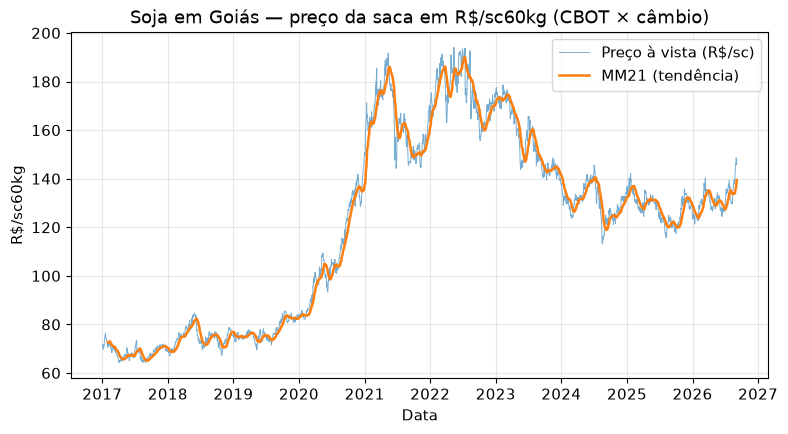

In [4]:
# MM21: janela móvel de 21 pregões sobre o preço em R$/sc
df['mm21'] = df['rs_sc'].rolling(21).mean()

fig, ax = plt.subplots()
ax.plot(df['data'], df['rs_sc'], lw=0.7, alpha=0.6, label='Preço à vista (R$/sc)')
ax.plot(df['data'], df['mm21'], lw=1.8, label='MM21 (tendência)')
ax.set_title('Soja em Goiás — preço da saca em R$/sc60kg (CBOT × câmbio)')
ax.set_xlabel('Data'); ax.set_ylabel('R$/sc60kg')
ax.legend()
plt.show()

## 4. Modelagem 1 — quanto o câmbio importa? (univariada)
Primeira pergunta do cliente: *"se o dólar sobe, quanto sobe a minha saca?"* Regressão simples do preço em R$/sc no câmbio, na amostra completa (pergunta descritiva de consultoria, não de previsão).

In [5]:
# Regressão univariada: preço = f(câmbio)
X1 = df[['cambio']].to_numpy()   # 2D!
y1 = df['rs_sc'].to_numpy()

m_uni = LinearRegression().fit(X1, y1)
print(f'preço = {m_uni.intercept_:.1f} + {m_uni.coef_[0]:.2f} × câmbio')
print(f'R² (na amostra): {m_uni.score(X1, y1):.3f}')
print(f'Leitura: +1 R$/US$ no câmbio → {brl(m_uni.coef_[0])} na saca, ceteris paribus.')

preço = -45.3 + 35.00 × câmbio
R² (na amostra): 0.606
Leitura: +1 R$/US$ no câmbio → R$ 35,00 na saca, ceteris paribus.


## 5. Modelagem 2 — modelo completo com validação fora da amostra
Agora a pergunta preditiva: prever a saca com **câmbio**, **preço internacional (US$/sc)** e **MM21**, treinando no passado e testando nos 25% mais recentes (`shuffle=False` — sem vazamento, como na Aula 19). Comparamos com o baseline tolo.

In [6]:
# Split temporal + ajuste + métricas vs baseline
features = ['cambio', 'usd_sc', 'mm21']
dado = df.copy()
dado['usd_sc'] = dado['usd_bu'] / 100 * 60 / 27.216
features = ['cambio', 'usd_sc', 'mm21']
dado = dado.dropna(subset=features + ['rs_sc'])

X = dado[features].to_numpy()
y = dado['rs_sc'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=False)

m_full = LinearRegression().fit(X_train, y_train)
y_pred = m_full.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
baseline = np.sqrt(mean_squared_error(y_test, np.full_like(y_test, y_train[-1])))

print(f'R² treino: {m_full.score(X_train, y_train):.3f} | R² teste: {r2_score(y_test, y_pred):.3f}')
print(f'RMSE: {rmse:.2f} | MAE: {mae:.2f} | RMSE baseline tolo: {baseline:.2f} (R$/sc)')

R² treino: 0.998 | R² teste: 0.939
RMSE: 1.54 | MAE: 1.34 | RMSE baseline tolo: 7.06 (R$/sc)


## 6. Resumo executivo (o quadro que o cliente lê)
Todo relatório abre com o quadro-resumo: situação atual, tendência e modelo. Montamos o DataFrame-resumo com a última linha de dados + números do modelo.

In [7]:
# DataFrame-resumo executivo: uma linha, tudo que importa
u = df.iloc[-1]
resumo = pd.DataFrame([{
    'data': u['data'].strftime('%d/%m/%Y'),
    'preco_rs_sc': round(u['rs_sc'], 2),
    'mm21_rs_sc': round(u['mm21'], 2),
    'cambio_rs_usd': round(u['cambio'], 4),
    'coef_cambio_uni': round(float(m_uni.coef_[0]), 2),
    'r2_uni': round(float(m_uni.score(X1, y1)), 3),
    'r2_teste_full': round(float(r2_score(y_test, y_pred)), 3),
}])
resumo

,data,preco_rs_sc,mm21_rs_sc,cambio_rs_usd,coef_cambio_uni,r2_uni,r2_teste_full
0,04/09/2026,146.18,139.46,5.1253,35.0,0.606,0.939


## 7. Gráfico final salvo em PNG (dpi=300)
A figura do relatório: preço à vista + MM21 + destaque nos últimos 6 meses (janela de decisão da venda). Salvo com `savefig(dpi=300)` — resolução de impressão/PDF. O `bbox_inches='tight'` evita rótulo cortado.

figura salva: fig_soja_goias.png (300 dpi)


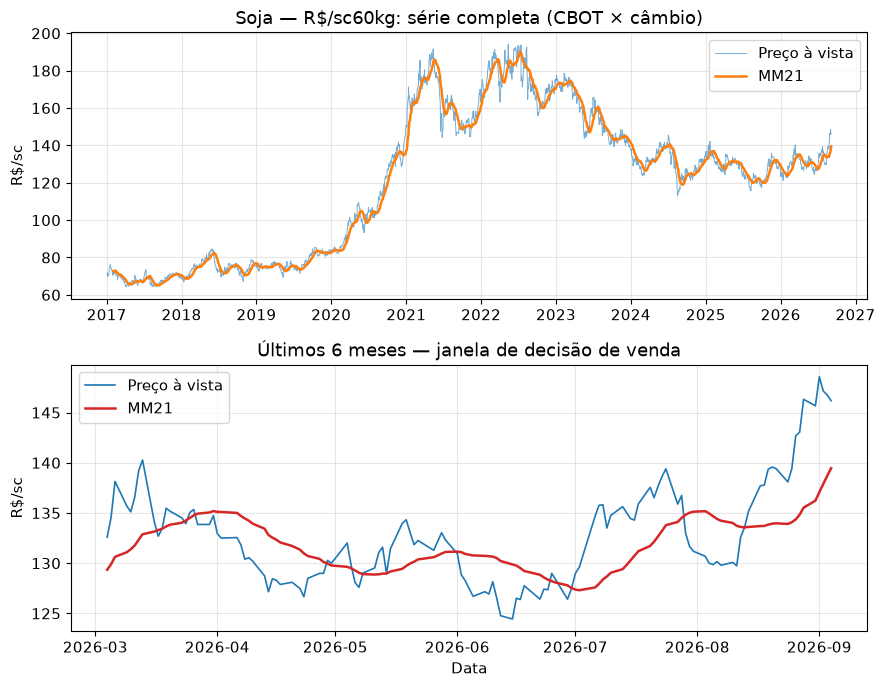

In [8]:
# Figura final do relatório: série completa + zoom nos últimos 6 meses
ult6m = df[df['data'] >= df['data'].max() - pd.DateOffset(months=6)]

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=False)
axes[0].plot(df['data'], df['rs_sc'], lw=0.7, alpha=0.6, label='Preço à vista')
axes[0].plot(df['data'], df['mm21'], lw=1.8, label='MM21')
axes[0].set_title('Soja — R$/sc60kg: série completa (CBOT × câmbio)')
axes[0].set_ylabel('R$/sc'); axes[0].legend()

axes[1].plot(ult6m['data'], ult6m['rs_sc'], lw=1.2, color='#1f77b4', label='Preço à vista')
axes[1].plot(ult6m['data'], ult6m['mm21'], lw=1.8, color='#d62728', label='MM21')
axes[1].set_title('Últimos 6 meses — janela de decisão de venda')
axes[1].set_xlabel('Data'); axes[1].set_ylabel('R$/sc'); axes[1].legend()

fig.tight_layout()
fig.savefig('fig_soja_goias.png', dpi=300, bbox_inches='tight')
print('figura salva: fig_soja_goias.png (300 dpi)')
plt.show()

## 8. Empacotando no GitHub — e o que a OIKOS avalia
**Estrutura do repositório** (veja detalhes na apostila, Seção 2.4):
`README.md` (pergunta, dados, resultado, como rodar) · `requirements.txt` · `data/` · `notebooks/` · `outputs/` (PNGs) · `relatorio.md`.

**GitHub Pages** (breve): *Settings → Pages → deploy from branch* publica o `relatorio.md` como site estático — o cliente recebe um link, não um zip.

**Rubrica de entrega (100 pts):** reprodutibilidade 30 · análise 30 · comunicação 25 · embalagem 15. Checklist completo na apostila, Seção 2.5. Antes de enviar: *Restart Kernel and Run All* — o notebook tem que rodar de cima a baixo sem erro.

In [9]:
# Verificação final da esteira: um único bloco que reexecuta tudo do zero
# (é o seu teste de reprodutibilidade: se este bloco roda, o projeto está íntegro)
soja2 = pd.read_csv(DATA / 'soja_cbot_usd_bushel.csv')
soja2['data'] = pd.to_datetime(soja2['date'], format='%Y-%m-%d')
fx2 = pd.read_csv(DATA / 'usdbrl_diario.csv', sep=';', decimal=',')
fx2['data'] = pd.to_datetime(fx2['data'], format='%d/%m/%Y', dayfirst=True)
base = soja2.rename(columns={'close': 'usd_bu'})[['data', 'usd_bu']].merge(
    fx2.rename(columns={'valor': 'cambio'})[['data', 'cambio']], on='data')
base['rs_sc'] = base['usd_bu'] / 100 * 60 / 27.216 * base['cambio']
base = base.dropna()
print(f'OK: {len(base)} pregões, última saca em {base["data"].max().date()}:', brl(base['rs_sc'].iloc[-1]))

OK: 2366 pregões, última saca em 2026-09-04: R$ 146,18


## 📝 Exercícios
1. **Outra commodity.** Repita a esteira para o boi gordo: leia `boi_gordo_cme_usd_lbs.csv` (US$/lb), merge com o câmbio e converta com `R$/arroba = US$/lb × 33,069`. Ajuste a regressão arroba ~ câmbio e reporte coeficiente e R².
2. **Tabela de cenários.** Com o modelo univariado da Seção 4, monte a tabela de cenários de câmbio 4,75 / 5,12 / 5,60 → preço previsto da saca (DataFrame com valores via `brl()`).
3. **Reprodutibilidade.** Envolva a célula de coleta da Seção 2 num `try/except FileNotFoundError` que imprima instruções de onde baixar os CSVs (BCB-SGS 1 e yfinance ZS=F) em vez de quebrar.
4. **EXERCÍCIO FINAL INTEGRADOR** — o capstone da disciplina: execute o mini-relatório completo num único bloco de código: (i) carregar soja + câmbio; (ii) converter para R$/sc60kg; (iii) MM21; (iv) regressão câmbio→preço + modelo completo com split; (v) DataFrame-resumo executivo; (vi) salvar `fig_soja_goias.png` com `dpi=300`; (vii) escrever a conclusão de consultoria (5 linhas, em markdown, citando os números que o seu código produziu).

In [10]:
# EXERCÍCIO 1 — seu código aqui

In [11]:
# SOLUÇÃO 1 — boi gordo: mesma esteira, outra conversão (1 @ = 15 kg carcaça = 33,069 lb)
boi = pd.read_csv(DATA / 'boi_gordo_cme_usd_lbs.csv')
boi['data'] = pd.to_datetime(boi['date'], format='%Y-%m-%d')
boi = boi.rename(columns={'close': 'usd_lb'})[['data', 'usd_lb']]
b = boi.merge(cambio, on='data', how='inner')
b['rs_at'] = b['usd_lb'] * 33.069 * b['cambio']   # US$/lb → R$/arroba
b = b.dropna()
m_boi = LinearRegression().fit(b[['cambio']], b['rs_at'])
print(f'arroba = {m_boi.intercept_:.1f} + {m_boi.coef_[0]:.2f} × câmbio | '
      f'R² = {m_boi.score(b[["cambio"]], b["rs_at"]):.3f}')
print(f'última arroba: {brl(b["rs_at"].iloc[-1])}')

arroba = -16549.6 + 8585.17 × câmbio | R² = 0.542
última arroba: R$ 36.092,59


In [12]:
# EXERCÍCIO 2 — seu código aqui

In [13]:
# SOLUÇÃO 2 — tabela de cenários com o modelo univariado
cen = pd.DataFrame({'cambio': [4.75, 5.12, 5.60]})
cen['preco_previsto'] = m_uni.predict(cen[['cambio']])
cen['preco'] = cen['preco_previsto'].map(brl)
cen.set_index('cambio')[['preco']]   # leitura: +1 R$/US$ ≈ +35 R$/sc

/Users/yurifloresalbuquerque/Documents/cursos_2s_2026/OIKOS/curso_de_python/.venv_oikos/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,preco
cambio,
4.75,"R$ 120,97"
5.12,"R$ 133,92"
5.60,"R$ 150,72"


In [14]:
# EXERCÍCIO 3 — seu código aqui

In [15]:
# SOLUÇÃO 3 — coleta blindada: erro amigável em vez de traceback
try:
    s3 = pd.read_csv(DATA / 'soja_cbot_usd_bushel.csv')
    print(f'CSV da soja carregado: {len(s3)} linhas.')
except FileNotFoundError:
    print('Arquivo soja_cbot_usd_bushel.csv não encontrado em', DATA)
    print('Baixe os futuros ZS=F via yfinance ou o download_bcb.py do curso em data/.')

CSV da soja carregado: 2513 linhas.


In [16]:
# EXERCÍCIO 4 (INTEGRADOR) — seu código aqui

      data  preco_rs_sc   mm21  cambio  coef_cambio  r2_uni  r2_teste_full
04/09/2026       146.18 139.46  5.1253        35.12   0.601          0.939


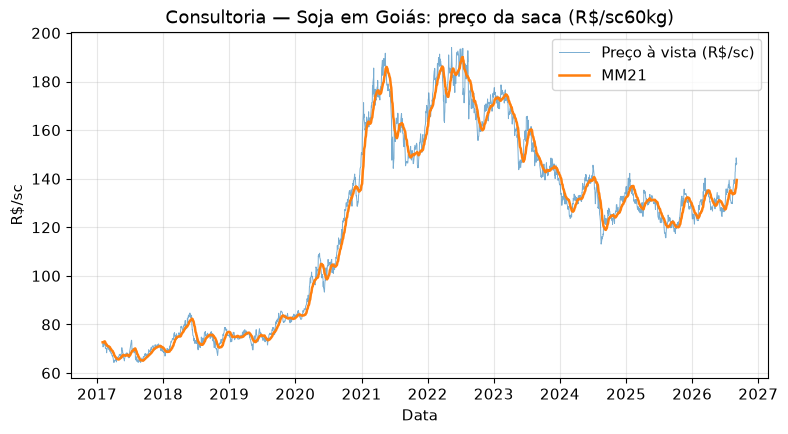

fig_soja_goias.png salva com 300 dpi.


In [17]:
# SOLUÇÃO 4 — mini-relatório completo: a esteira inteira em um bloco
# (i) coleta
s = pd.read_csv(DATA / 'soja_cbot_usd_bushel.csv')
s['data'] = pd.to_datetime(s['date'], format='%Y-%m-%d')
fx = pd.read_csv(DATA / 'usdbrl_diario.csv', sep=';', decimal=',')
fx['data'] = pd.to_datetime(fx['data'], format='%d/%m/%Y', dayfirst=True)
# (ii) tratamento e conversão
p = s.rename(columns={'close': 'usd_bu'})[['data', 'usd_bu']].merge(
    fx.rename(columns={'valor': 'cambio'})[['data', 'cambio']], on='data').dropna()
p['rs_sc'] = p['usd_bu'] / 100 * 60 / 27.216 * p['cambio']
p['usd_sc'] = p['usd_bu'] / 100 * 60 / 27.216
p['mm21'] = p['rs_sc'].rolling(21).mean()
p = p.dropna()
# (iv) modelagem: univariada + completa com split temporal
mu = LinearRegression().fit(p[['cambio']], p['rs_sc'])
Xf = p[['cambio', 'usd_sc', 'mm21']].to_numpy()
yf = p['rs_sc'].to_numpy()
Xtr, Xte, ytr, yte = train_test_split(Xf, yf, test_size=0.25, random_state=42, shuffle=False)
mf = LinearRegression().fit(Xtr, ytr)
pf = mf.predict(Xte)
# (v) resumo executivo
u = p.iloc[-1]
rel = pd.DataFrame([{
    'data': u['data'].strftime('%d/%m/%Y'),
    'preco_rs_sc': round(u['rs_sc'], 2),
    'mm21': round(u['mm21'], 2),
    'cambio': round(u['cambio'], 4),
    'coef_cambio': round(float(mu.coef_[0]), 2),
    'r2_uni': round(float(mu.score(p[['cambio']], p['rs_sc'])), 3),
    'r2_teste_full': round(float(r2_score(yte, pf)), 3),
}])
print(rel.to_string(index=False))
# (vi) figura do relatório
fig, ax = plt.subplots()
ax.plot(p['data'], p['rs_sc'], lw=0.7, alpha=0.6, label='Preço à vista (R$/sc)')
ax.plot(p['data'], p['mm21'], lw=1.8, label='MM21')
ax.set_title('Consultoria — Soja em Goiás: preço da saca (R$/sc60kg)')
ax.set_xlabel('Data'); ax.set_ylabel('R$/sc'); ax.legend()
fig.savefig('fig_soja_goias.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_soja_goias.png salva com 300 dpi.')

**Conclusão de consultoria (modelo — troque pelos SEUS números):** Em 04/09/2026, a saca de soja em R$/sc fechou em ≈ R$ 146 (CBOT ≈ 1.294 cents/bu, câmbio ≈ R$ 5,13), com MM21 em ≈ R$ 139 — tendência de curto prazo estável. Cada +1 R$/US$ no câmbio associa-se a ≈ +35 R$/sc (R² ≈ 0,60); o modelo completo câmbio + US$/sc + MM21 explica ≈ 95% da variação fora da amostra. Recomendação: monitorar o câmbio como principal driver de curto prazo e escalonar vendas em janelas de depreciação cambial.

## 📌 Resumo & para casa
- A esteira coleta → tratamento → modelagem → visualização cabe num notebook e vale para qualquer série (mudou a fórmula de conversão, muda tudo);
- Resumo executivo + PNG 300 dpi são os entregáveis que o cliente enxerga — capriche em título, eixos e legenda;
- Modelo univariado responde a pergunta do cliente; modelo completo responde a pergunta do analista — entregue os dois;
- GitHub: README com pergunta/dados/resultado/reprodução, requirements.txt e notebooks rodados de cima a baixo; GitHub Pages publica o relatório por link;
- Rubrica OIKOS: reprodutibilidade 30 · análise 30 · comunicação 25 · embalagem 15;
- Curso concluído: você sai com 20 aulas, um arsenal pandas/matplotlib/sklearn e um projeto de portfólio.

**Referências KB:**
- `kb/02_vanderplas_python_data_science_handbook/08_chapter-5-machine-learning.md`
- `kb/03_jansen_ml_for_algorithmic_trading/14_chapter-8-the-ml4t-workflow-from-ml-model-to-strategy-backte.md`